In [ ]:
# 1. Verificar la GPU
# Asegúrate de que en el menú "Entorno de ejecución" -> "Cambiar tipo de entorno de ejecución" esté seleccionada la GPU (T4 es ideal).
!nvidia-smi

# 2. Instalar Ultralytics (la librería de YOLOv8)
# Usamos 'quiet' para reducir el spam en la salida
!pip install ultralytics -q

# 3. Montar Google Drive
# Esto te pedirá autorización. Sigue el enlace y pega el código.
from google.colab import drive
drive.mount('/content/drive')

Thu Oct 30 22:43:29 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="enBANO0kCm6EIJz2gxop")
project = rf.workspace("proyecto-leom").project("orange-detection-1fyn0-0jtlt")
version = project.version(1)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 108.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Orange-Detection-1 in yolov8:: 100%|██████████| 6012/6012 [00:05<00:00, 1091.05it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
print(f"Dataset descargado en: {dataset.location}")
print(f"El archivo YAML está en: {dataset.location}/data.yaml")

Dataset descargado en: /content/Orange-Detection-1
El archivo YAML está en: /content/Orange-Detection-1/data.yaml


In [ ]:
# 4. Importar YOLO y cargar el modelo
from ultralytics import YOLO

# Cargamos el modelo de SEGMENTACIÓN
model = YOLO('yolov8n-seg.pt')

In [ ]:
results = model.train(
    data=dataset.location + '/data.yaml',

    # --- Estrategia de Entrenamiento (se mantiene) ---
    epochs=300,
    patience=20,

    # --- Parámetros de Velocidad (se mantienen) ---
    batch=96,
    workers=14,
    cache=True,

    # --- Aumentos de Datos Base (se mantienen) ---
    degrees=20.0,
    flipud=0.5,

    # --- NUEVOS AUMENTOS DE DATOS (Nivel 2) ---
    scale=0.5,        # (Valor por defecto, pero ahora explícito)
    translate=0.1,    # (Valor por defecto, pero ahora explícito)
    mixup=0.15,        # 10% de probabilidad de MixUp
    copy_paste=0.15,   # 10% de probabilidad de CopyPaste (¡genial para seg!)

    # --- Gestión de proyecto ---
    project='/content/drive/MyDrive/MiProyectoPPS/training_runs',
    name='naranjas_seg_v5_full_aug' # ¡Nuevo nombre para el mejor experimento!
)


Ultralytics 8.3.222 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=96, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.15, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Orange-Detection-1/data.yaml, degrees=20.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=naranjas_seg_v5_full_aug, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, p

In [ ]:
from ultralytics import YOLO
import os

# --- 1. Definir Ubicaciones ---

# Esta es la ruta a tu modelo final. ¡Es correcta!
path_modelo = '/content/drive/MyDrive/MiProyectoPPS/training_runs/naranjas_seg_v5_full_aug/weights/best.pt'

# Esta es la ruta al archivo .yaml que define tu dataset
# (Asume que ejecutaste la celda de Roboflow en Paso 1)
data_yaml_path = os.path.join(dataset.location, 'data.yaml')


# --- 2. Cargar y Probar el Modelo ---

# Carga tu modelo entrenado
model = YOLO(path_modelo)

# Ejecuta la validación (model.val) en el conjunto de 'test'
print("Iniciando validación en el conjunto de TEST...")
metrics = model.val(
    data=data_yaml_path,
    split='test'
)

# --- 3. Imprimir Resultados Clave (¡CORREGIDO!) ---

print("\n--- ¡Validación Completa! ---")
print("--- Métricas de Precisión (mAP) para MÁSCARAS ---")
# CORRECCIÓN: Se usa 'metrics.seg' en lugar de 'metrics.mask'
print(f"  mAP50-95 (Promedio): {metrics.seg.map:.4f}")
print(f"  mAP50 (Fácil): {metrics.seg.map50:.4f}")
print(f"  mAP75 (Difícil): {metrics.seg.map75:.4f}")

print("\n--- Métricas de Precisión (mAP) para CAJAS ---")
# Las métricas de 'box' sí están en 'metrics.box'
print(f"  mAP50-95 (Promedio): {metrics.box.map:.4f}")
print(f"  mAP50 (Fácil): {metrics.box.map50:.4f}")
print(f"  mAP75 (Difícil): {metrics.box.map75:.4f}")

print("\n--- Ubicación de los gráficos (Matriz de Confusión, etc.) ---")
print(f"Los gráficos se guardaron en: {metrics.save_dir}")

Iniciando validación en el conjunto de TEST...
Ultralytics 8.3.223 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-seg summary (fused): 85 layers, 3,258,649 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4000.5±539.4 MB/s, size: 400.9 KB)
val: Scanning /content/Orange-Detection-1/test/labels.cache... 600 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 600/600 1.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 1.6it/s 24.1s
                   all        600        700      0.988      0.959      0.987      0.929      0.988      0.959      0.987      0.921
   Green_Orange_Indoor        200        200          1          1      0.995      0.989          1          1      0.995      0.987
   Green_Orange_Normal        225        253      0.992       0.93       0.99      0.935      0.992       0.93       0.

Iniciando validación en el conjunto de TEST...
Ultralytics 8.3.223 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-seg summary (fused): 85 layers, 3,258,649 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3719.2±585.8 MB/s, size: 331.0 KB)
val: Scanning /content/Orange-Detection-1/test/labels.cache... 600 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 600/600 910.5Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 1.1it/s 33.3s
                   all        600        700      0.988      0.959      0.987      0.929      0.988      0.959      0.987      0.921
   Green_Orange_Indoor        200        200          1          1      0.995      0.989          1          1      0.995      0.987
   Green_Orange_Normal        225        253      0.992       0.93       0.99      0.935      0.992       0.93       

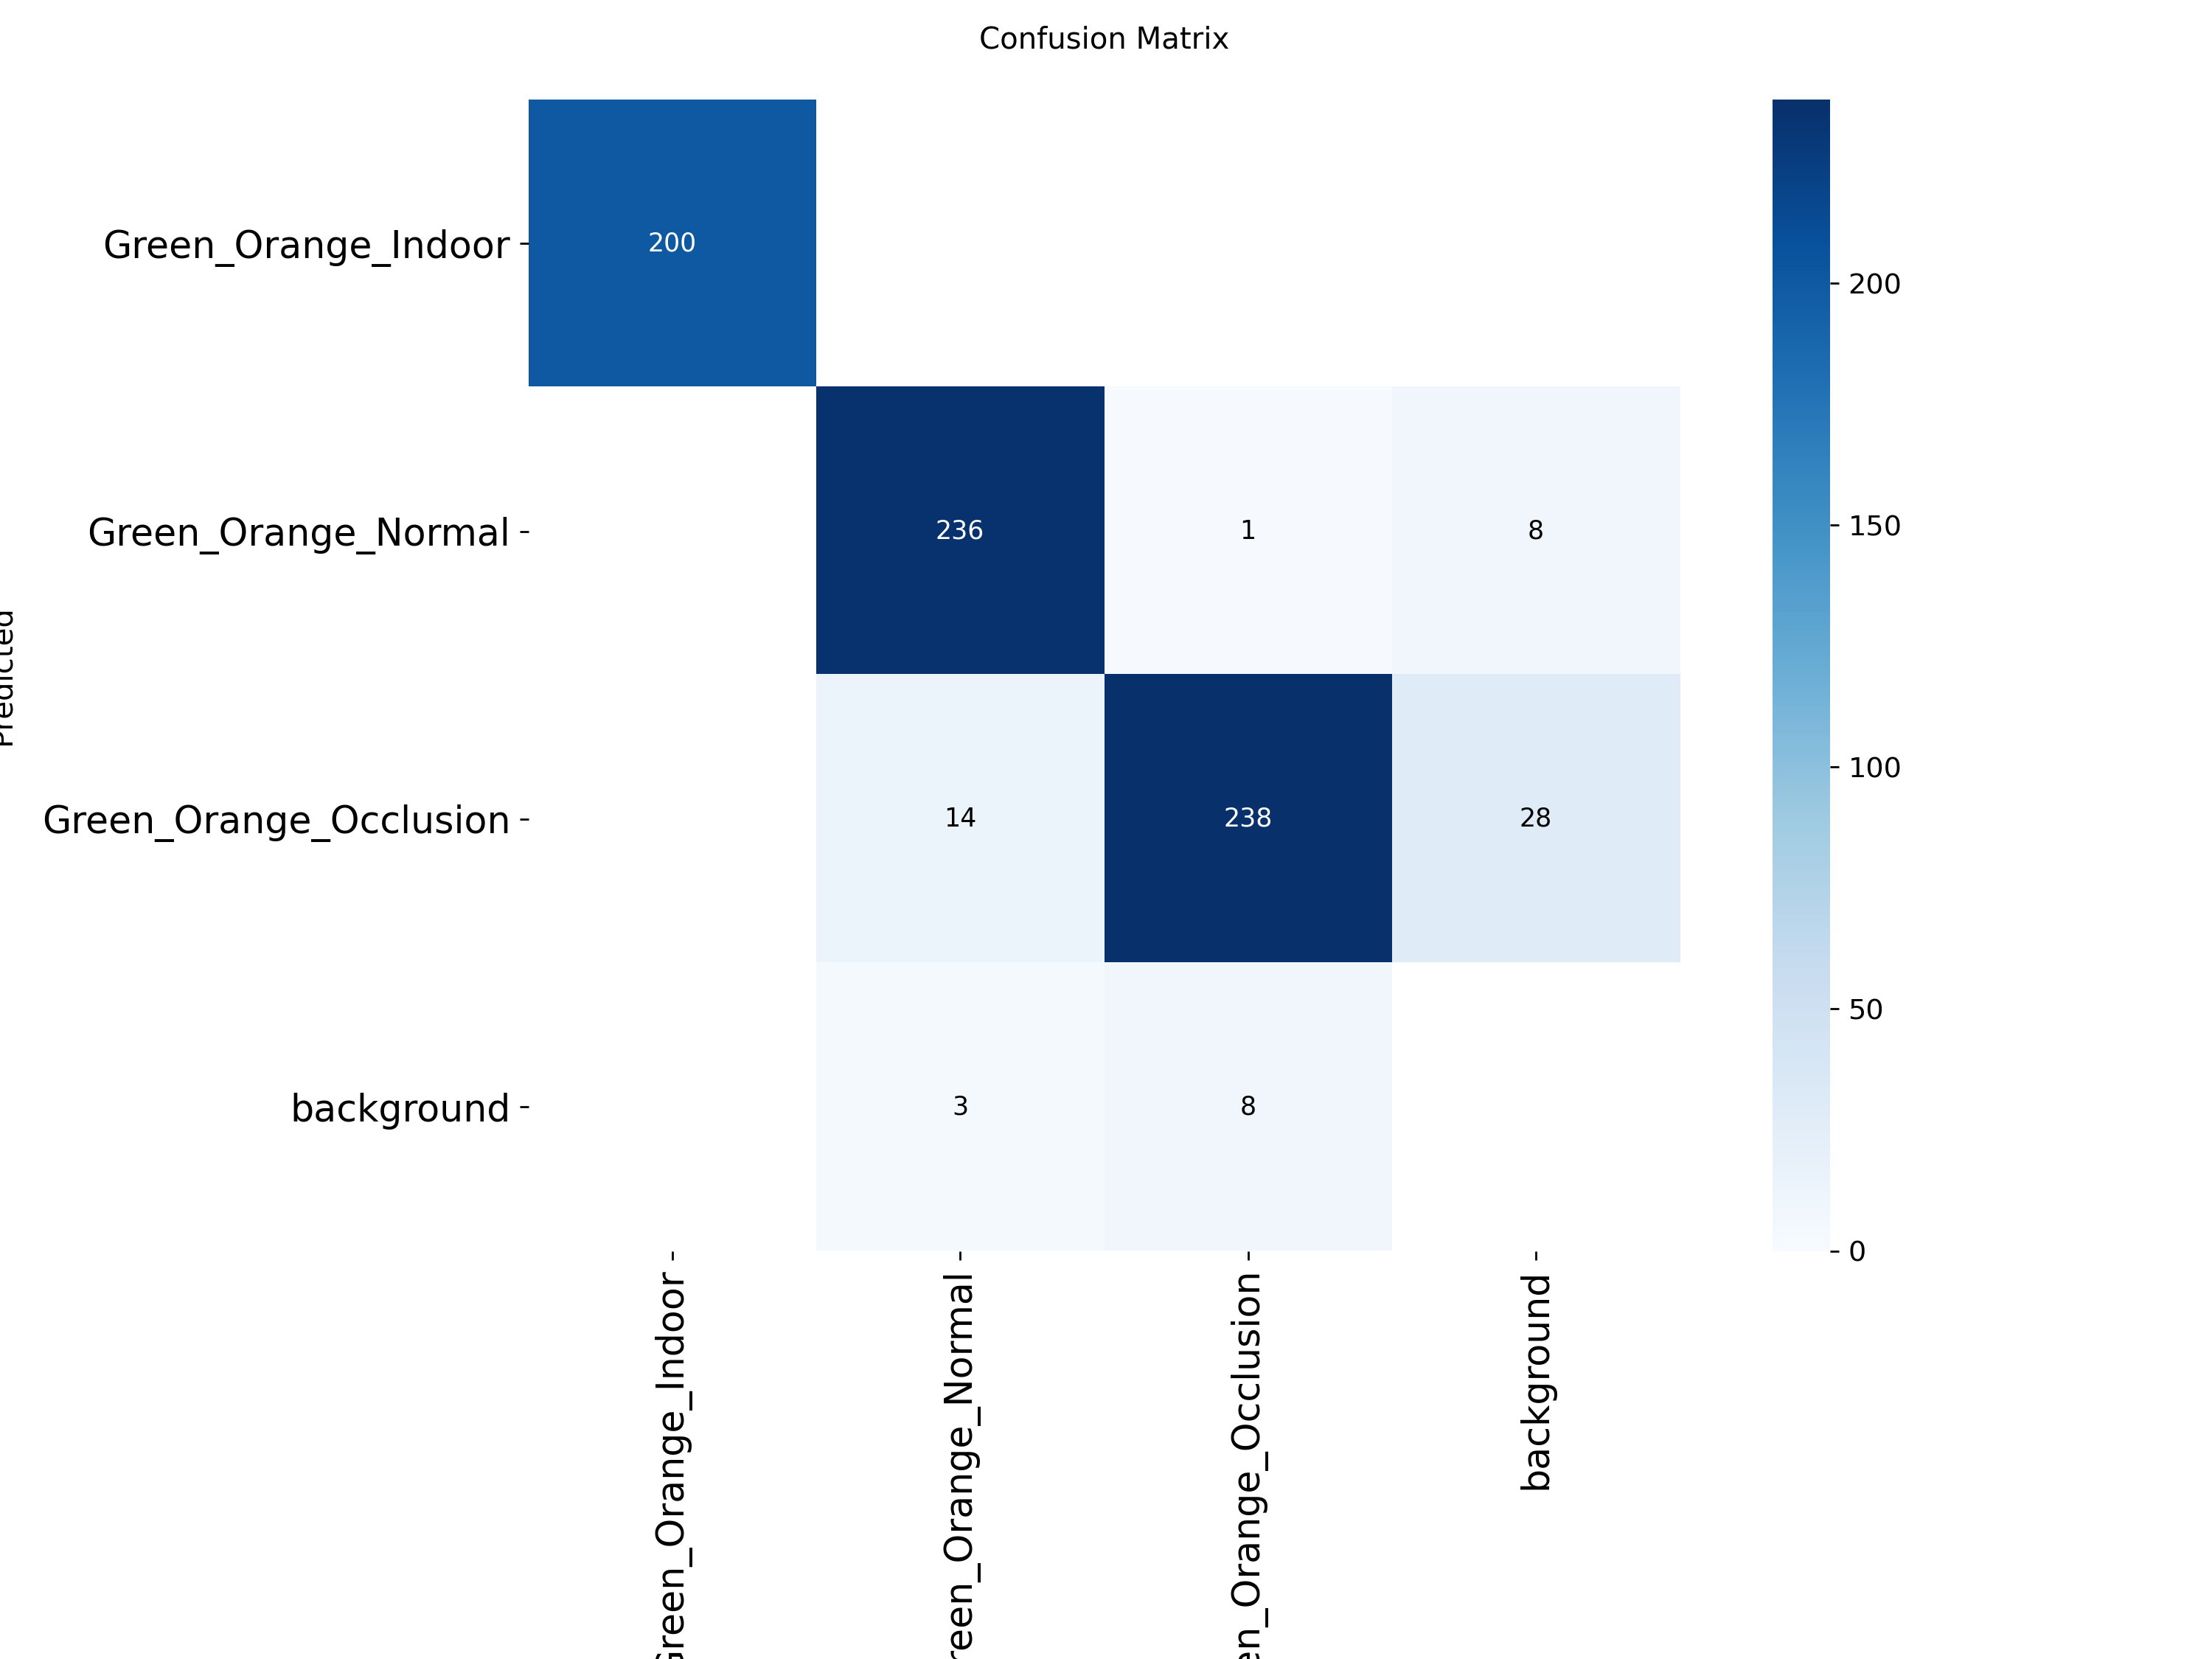


Mostrando Lote de Predicciones (Batch 0):


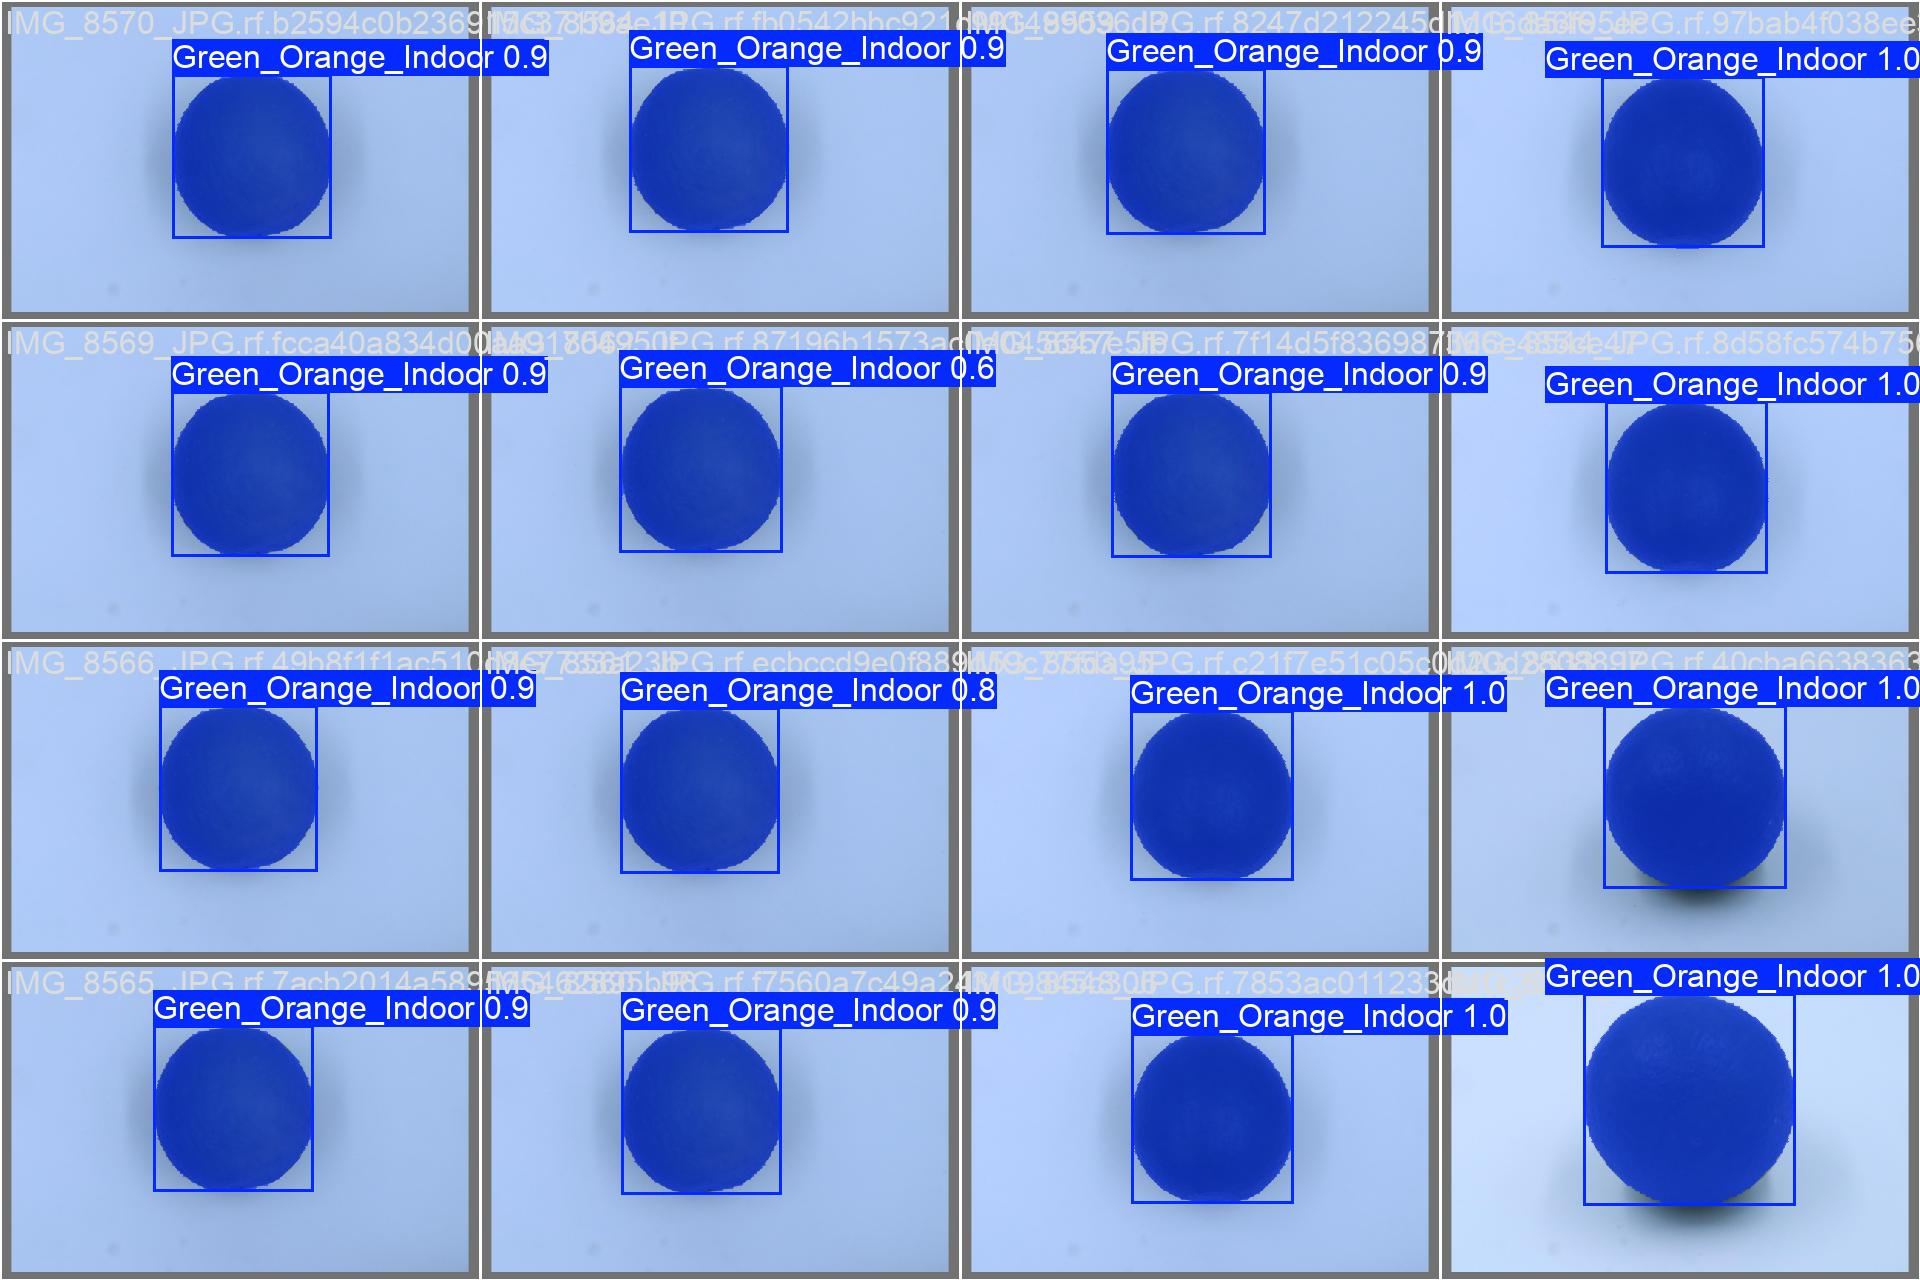

In [ ]:
from ultralytics import YOLO
import os
from IPython.display import Image, display # ¡Importante para mostrar imágenes!

# --- 1. Definir Ubicaciones ---

# Esta es la ruta a tu modelo final. ¡Es correcta!
path_modelo = '/content/drive/MyDrive/MiProyectoPPS/training_runs/naranjas_seg_v5_full_aug/weights/best.pt'

# Esta es la ruta al archivo .yaml que define tu dataset
# (Asume que ejecutaste la celda de Roboflow en Paso 1)
data_yaml_path = os.path.join(dataset.location, 'data.yaml')


# --- 2. Cargar y Probar el Modelo ---

# Carga tu modelo entrenado
model = YOLO(path_modelo)

# Ejecuta la validación (model.val) en el conjunto de 'test'
print("Iniciando validación en el conjunto de TEST...")
metrics = model.val(
    data=data_yaml_path,
    split='test'
)

# --- 3. Imprimir Resultados Clave (Corregido) ---

print("\n--- ¡Validación Completa! ---")
print("--- Métricas de Precisión (mAP) para MÁSCARAS ---")
print(f"  mAP50-95 (Promedio): {metrics.seg.map:.4f}")
print(f"  mAP50 (Fácil): {metrics.seg.map50:.4f}")
print(f"  mAP75 (Difícil): {metrics.seg.map75:.4f}")

print("\n--- Métricas de Precisión (mAP) para CAJAS ---")
print(f"  mAP50-95 (Promedio): {metrics.box.map:.4f}")
print(f"  mAP50 (Fácil): {metrics.box.map50:.4f}")
print(f"  mAP75 (Difícil): {metrics.box.map75:.4f}")

print("\n--- Ubicación de los gráficos (Matriz de Confusión, etc.) ---")
print(f"Los gráficos se guardaron en: {metrics.save_dir}")


# --- 4. NUEVO: Mostrar las Imágenes de Resultados ---

print("\n--- 4. Visualización de Resultados ---")

# Ruta a la carpeta de resultados
results_dir = metrics.save_dir

# 1. Mostrar la Matriz de Confusión
path_matriz_confusion = os.path.join(results_dir, 'confusion_matrix.png')
if os.path.exists(path_matriz_confusion):
    print(f"\nMostrando Matriz de Confusión:")
    display(Image(filename=path_matriz_confusion))
else:
    print("\nNo se encontró la Matriz de Confusión.")

# 2. Mostrar la "matriz" de imágenes predichas (el primer lote)
path_predicciones = os.path.join(results_dir, 'val_batch0_pred.jpg')
if os.path.exists(path_predicciones):
    print(f"\nMostrando Lote de Predicciones (Batch 0):")
    display(Image(filename=path_predicciones))
else:
    print("\nNo se encontró el lote de imágenes de predicción.")